In [66]:
!pwd

/media/admin1/2/MSc_bioinformatics/ML/numpy_pandas


In [4]:
import pandas as pd
import numpy as np
# Sample data
data = {
    "Department": ["HR", "IT", "HR", "Finance", "IT", "Finance",'IT'],
    "Employee": ["Alice", "Bob", "Charlie", "David", "Eva", "Frank",'Mac'],
    "Salary": [50000, 60000, 52000, 58000, 62000, 60000,np.nan],
    "Experience": [2, 5, 3, 7, 4, 6, 5]
}

df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)

# Group by Department and calculate average Salary
grouped = df.groupby("Department")["Salary"].mean()

print("\nAverage Salary by Department:")
print(grouped)


Original DataFrame:
  Department Employee   Salary  Experience
0         HR    Alice  50000.0           2
1         IT      Bob  60000.0           5
2         HR  Charlie  52000.0           3
3    Finance    David  58000.0           7
4         IT      Eva  62000.0           4
5    Finance    Frank  60000.0           6
6         IT      Mac      NaN           5

Average Salary by Department:
Department
Finance    59000.0
HR         51000.0
IT         61000.0
Name: Salary, dtype: float64


In [37]:
# Count how many employees per department
print(df.groupby("Department")["Employee"].count())

Department
Finance    2
HR         2
IT         3
Name: Employee, dtype: int64


In [39]:
# Salary grouped by Department and Experience
print(df.groupby(["Department", "Experience"])["Salary"].mean())

Department  Experience
Finance     6             60000.0
            7             58000.0
HR          2             50000.0
            3             52000.0
IT          4             62000.0
            5             60000.0
Name: Salary, dtype: float64


In [40]:
# Total salary per department
print(df.groupby("Department")["Salary"].sum())


Department
Finance    118000.0
HR         102000.0
IT         122000.0
Name: Salary, dtype: float64


In [47]:
# For each department: average salary and max experience
print(df.groupby("Department").agg({"Salary": "mean", "Experience": "max"}))



                  Salary  Experience
Department                          
Finance     59000.000000           7
HR          51000.000000           3
IT          59666.666667           5


"""df.groupby("Department") → groups data by unique Department values (HR, IT, Finance).

.agg({...}) → lets you apply different functions to different columns at the same time:

"Salary": "mean" → calculates average salary in each department.

"Experience": "max" → finds the maximum experience in each department.

The result is a new DataFrame with multiple summary stats per group."""

In [49]:
#Unique values
print("Unique Age values:", df['Salary'].unique())
# Explanation: Shows unique values in Age column (including NaN if present).

Unique Age values: [50000. 60000. 52000. 58000. 62000. 57000.]


In [44]:
df['Salary'].fillna(df['Salary'].mean(), inplace=True) #dictates whether the operation modifies the original DataFrame directly or returns a new DataFrame with the changes.
print("\nAfter filling NaN with mean Age:")
print(df)
#inplace=False (the default behavior):
#The operation returns a copy of the DataFrame with the changes applied.
#The original DataFrame remains unchanged.


After filling NaN with mean Age:
  Department Employee   Salary  Experience
0         HR    Alice  50000.0           2
1         IT      Bob  60000.0           5
2         HR  Charlie  52000.0           3
3    Finance    David  58000.0           7
4         IT      Eva  62000.0           4
5    Finance    Frank  60000.0           6
6         IT      Mac  57000.0           5


/tmp/ipykernel_12063/3120088620.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(df['Salary'].mean(), inplace=True) #dictates whether the operation modifies the original DataFrame directly or returns a new DataFrame with the changes.


In [6]:
# 26. Drop missing values (let’s add another NaN for demo)
df.loc[1, 'Salary'] = np.nan   # make Bob's Age missing again
df.dropna(inplace=True)
#print("\nAfter dropping rows with NaN:")
print(df)

  Department Employee   Salary  Experience
0         HR    Alice  50000.0           2
2         HR  Charlie  52000.0           3
3    Finance    David  58000.0           7
4         IT      Eva  62000.0           4
5    Finance    Frank  60000.0           6


In [7]:
# 27. Check for null values
print("\nNull values count per column:")
print(df.isnull().sum())
# Explanation: Counts null values in each column.


Null values count per column:
Department    0
Employee      0
Salary        0
Experience    0
dtype: int64


In [56]:
df = pd.DataFrame({"A": [10, 20, 30], "B": [40, 50, 60]}, index=["x", "y", "z"])
df
   # ?

,A,B
x,10,40
y,20,50
z,30,60


In [63]:
print(df.loc["y"])    
print(df.iloc[1])   

A    20
B    50
Name: y, dtype: int64
A    20
B    50
Name: y, dtype: int64


In [64]:
. What happens when you sort NaN values?
df = pd.DataFrame({"A": [3, np.nan, 2, 1]})
print(df.sort_values("A"))

Object `values` not found.
     A
3  1.0
2  2.0
0  3.0
1  NaN


Slope (m): 9.556840077071291
Intercept (c): 13.410404624277454


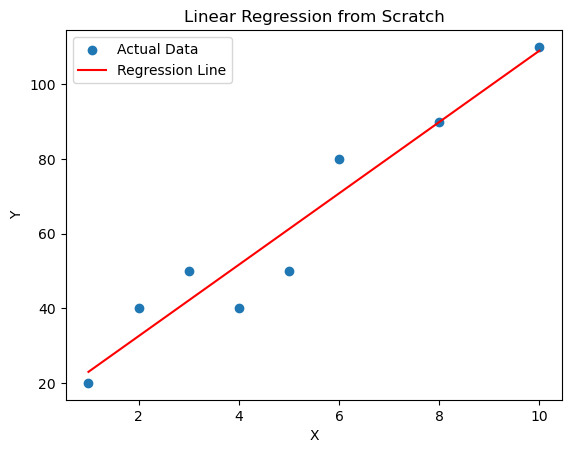

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
X = np.array([1, 2, 3, 4, 5,6,8,10])
Y = np.array([20, 40, 50, 40, 50,80,90,110])

# Calculate N
N = len(X)

# Calculate sums
sum_XY = np.sum(X * Y) #element-wise multiplication of arrays.
sum_X = np.sum(X) #np.sum(...) → adds all products.
sum_Y = np.sum(Y) #sum_XY = Σ(Xi·Yi) (sum of products of corresponding x and y)
sum_X_squared = np.sum(X**2)

# Calculate slope (m) and intercept (c)
m = (N * sum_XY - sum_X * sum_Y) / (N * sum_X_squared - sum_X**2)
c = (sum_Y - m * sum_X) / N

print(f"Slope (m): {m}")
print(f"Intercept (c): {c}")

# Predict values
Y_pred = m * X + c

# Plotting
plt.scatter(X, Y, label='Actual Data')
plt.plot(X, Y_pred, color='red', label='Regression Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression from Scratch')
plt.legend()
plt.show()